In [4]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from operator import add
# 1 定义状态
class OverAllState(TypedDict):
    logs:Annotated[list[str],add]
    cur_id:str


# 2. 定义节点
def node_1(state:OverAllState)->OverAllState:
    pre_id = state['cur_id']
    return {
        "logs":["node_1运行完毕"],
        "cur_id":pre_id+",node_1"
    }

def node_2(state:OverAllState)->OverAllState:
    pre_id = state['cur_id']
    return {
        "logs":["node_2运行完毕"],
        "cur_id":pre_id+",node_2"
    }

# 3 定义边
# 3.1 创建图 获取建造者
builder = StateGraph(state_schema=OverAllState)
#3.2 添加节点
builder.add_node("node_1",node_1)
builder.add_node("node_2",node_2)
# 3.3 添加边
builder.add_edge(START,"node_1")
builder.add_edge("node_1","node_2")
builder.add_edge("node_2",END)

# 4 获取图
graph = builder.compile()

#5. 运行图
result = graph.invoke({"cur_id":"start"})
print(result)

{'logs': ['node_1运行完毕', 'node_2运行完毕'], 'cur_id': 'start,node_1,node_2'}


In [5]:
raw_mermaid = graph.get_graph().draw_mermaid()
print(raw_mermaid)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	node_1(node_1)
	node_2(node_2)
	__end__([<p>__end__</p>]):::last
	__start__ --> node_1;
	node_1 --> node_2;
	node_2 --> __end__;
	classDef default fill:#f2f0ff,line-height:1.2
	classDef first fill-opacity:0
	classDef last fill:#bfb6fc



b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00j\x00\x00\x01M\x08\x02\x00\x00\x00g\x9dm\xfa\x00\x00\x10\x00IDATx\x9c\xec\x9d\t@\x13\xc7\xde\xc0\'\x17\x84\x04B \xdc\xf7%\x08\xa8\xe0UoQ\xd1\xeak\xb5\x8a\xb7(\xad\xad\xda\xd6g\xab\xadG\xdf\xa1}\xfd\xac\xda\xda\xfalm}^\xbc\xa7\xd5\xaah\xab>\xc5\xe3Y\x8f\xe2\x05Z\x8fz\xa2\xa2\x82\x82\xdcwB\x0erl\x92oB(\xa2&\xd9\x84!qM\xe6W\xdb\xae\xbb\xb3\x9b\xf0cvfvfv\xfeL\xadV\x0b0m\x85\x0e0\x08`}H`}H`}H`}H`}H0\x01\x1a\x85\xb7\xe5\xf7\x7f\x17\tkU\x1a\xb5V!\xd3\x80V\xad \x1a\x1dh5O%n\xde\xc3\x00@M\x96F\xbf\xcd\x00Z\xb5\xe1d\xcf$\xa63\x80Fm\xea\xa3[Cg\xd1\xd8\x1c\x86+\x9f\x19\x12\xc3\x8d\xef\xe3\n\x10\xa0\xb5\xad\xddw-\xab\xe1Fv\xbdLL\x00\r`0i,6\x9d\xcd\xa1\xab\xd5Z\xad\xfa\xc9\xd5ht\x9aV\xf3\xd4\xc5\xf5{\xe8L\x9a\x86\xd0\x1aO\xd3J\x1f\x93\xa6mJ\xf9|\xb2gNg\xb0\x80Z\x05L|tk\xe8\x0c:\xfc\xa9\t\x85V\xa1Pk4\x00\xaa\x0c\x8fw\x1d<\xd1\x0bX\x8e\xc5\xfa\xaef\t\x7f?Q\x07-y\x07:\xf7\x1c\xea\x1d\x12\xeb\x04^f\xc4u\xdas\x99\x95\xa5\xf9\x8djB\x13\xde\xc9mx\x9a\x8fE\xa

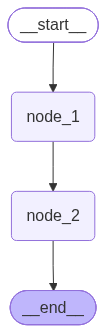

In [7]:
from IPython.display import display,Image

png_bytes = graph.get_graph().draw_mermaid_png()
print(png_bytes)
png = Image(png_bytes)
display(png)

In [8]:
png_bytes = graph.get_graph().draw_mermaid_png()
print(png_bytes)
png_filename = 'first_demo_graph.png'
with open(png_filename,"wb") as f:
    f.write(png_bytes)

b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x00j\x00\x00\x01M\x08\x02\x00\x00\x00g\x9dm\xfa\x00\x00\x10\x00IDATx\x9c\xec\x9d\t@\x13\xc7\xde\xc0\'\x17\x84\x04B \xdc\xf7%\x08\xa8\xe0UoQ\xd1\xeak\xb5\x8a\xb7(\xad\xad\xda\xd6g\xab\xadG\xdf\xa1}\xfd\xac\xda\xda\xfalm}^\xbc\xa7\xd5\xaah\xab>\xc5\xe3Y\x8f\xe2\x05Z\x8fz\xa2\xa2\x82\x82\xdcwB\x0erl\x92oB(\xa2&\xd9\x84!qM\xe6W\xdb\xae\xbb\xb3\x9b\xf0cvfvfv\xfeL\xadV\x0b0m\x85\x0e0\x08`}H`}H`}H`}H`}H0\x01\x1a\x85\xb7\xe5\xf7\x7f\x17\tkU\x1a\xb5V!\xd3\x80V\xad \x1a\x1dh5O%n\xde\xc3\x00@M\x96F\xbf\xcd\x00Z\xb5\xe1d\xcf$\xa63\x80Fm\xea\xa3[Cg\xd1\xd8\x1c\x86+\x9f\x19\x12\xc3\x8d\xef\xe3\n\x10\xa0\xb5\xad\xddw-\xab\xe1Fv\xbdLL\x00\r`0i,6\x9d\xcd\xa1\xab\xd5Z\xad\xfa\xc9\xd5ht\x9aV\xf3\xd4\xc5\xf5{\xe8L\x9a\x86\xd0\x1aO\xd3J\x1f\x93\xa6mJ\xf9|\xb2gNg\xb0\x80Z\x05L|tk\xe8\x0c:\xfc\xa9\t\x85V\xa1Pk4\x00\xaa\x0c\x8fw\x1d<\xd1\x0bX\x8e\xc5\xfa\xaef\t\x7f?Q\x07-y\x07:\xf7\x1c\xea\x1d\x12\xeb\x04^f\xc4u\xdas\x99\x95\xa5\xf9\x8djB\x13\xde\xc9mx\x9a\x8fE\xa

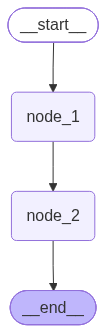

In [9]:
from IPython.display import display
display(graph)